In [1]:
import scarf

scarf.configure_output(level="ERROR", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
)

reader = scarf.CrH5Reader(f"{dataset}/data.h5")
scarf.CrToZarr(
    reader,
    zarr_loc=f"{dataset}/data.zarr",
).dump(batch_size=1000)

In [2]:
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)

In [3]:
artifacts = ds.pipeline.run()

In [4]:
sorted(artifacts)

['ann_index',
 'cell_cycle',
 'cell_selection',
 'connectivity_map',
 'doublets',
 'embedding_initialization',
 'highly_variable_features',
 'leiden_0.5',
 'leiden_0.75',
 'leiden_1.0',
 'leiden_1.25',
 'markers',
 'neighbors',
 'normalized',
 'paris',
 'pca',
 'selected_clusters',
 'umap']

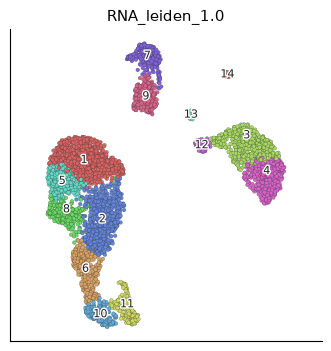

In [5]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="RNA_leiden_1.0",
)